In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ks_2samp

In [2]:
path_mc = "chunks_MC/"
path_data = "chunks/"

mc_chunks = {}
data_chunks = {}

In [3]:
for i in range(5):
    mc_chunks[i] = np.load(f"{path_mc}mc_chunk_{i+1:02d}.npz")

for i in range(28):
    data_chunks[i] = np.load(f"{path_data}data_chunk_{i+1:02d}.npz")

pT_j1: chunk 0 vs 0 → KS=0.000, p=1.000
pT_j1: chunk 0 vs 1 → KS=0.000, p=0.524
pT_j1: chunk 0 vs 2 → KS=0.000, p=0.845
pT_j1: chunk 0 vs 3 → KS=0.000, p=0.693
pT_j1: chunk 0 vs 4 → KS=0.000, p=0.707


KeyboardInterrupt: 

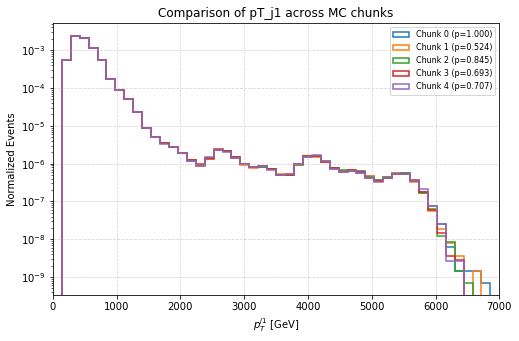

In [4]:
# variables = [
#     'pT_j1', 'eta_j1', 'phi_j1', 'pT_j2', 'eta_j2', 'phi_j2',
#     'm_jj', 'tau21_j1', 'tau21_j2', 'tau32_j1', 'tau32_j2',
#     'met', 'phi_met', 'min_dPhi', 'ht'
# ]

# # loop through all variables


# for var in variables:
#     plt.figure(figsize=(8,5))
#     base = mc_chunks[0][var]    
#     for i in mc_chunks:
#         # if i == 0: continue
#         stat, pval = ks_2samp(base, mc_chunks[i][var])
#         print(f"{var}: chunk 0 vs {i} → KS={stat:.3f}, p={pval:.3f}")
#         data = mc_chunks[i][var]
#         plt.hist(
#             data, bins=80, histtype='step',
#             linewidth=1.5, label=f'Chunk {i}', density=True
#         )
    
#     plt.xlabel(var)
#     plt.ylabel('Normalized events')
#     plt.title(f'Comparison of {var} across chunks')
#     plt.legend()
#     plt.grid(True, linestyle='--', alpha=0.5)
#     plt.tight_layout()
#     plt.show()

# Dictionary: variable -> (xmin, xmax, nbins, xlabel, log_scale)
VARIABLES = {
    "pT_j1": (0, 7000, 50, r"$p_{T}^{j1}$ [GeV]", True),
    "pT_j2": (0, 7000, 50, r"$p_{T}^{j2}$ [GeV]", True),
    "eta_j1": (-3, 3, 15, r"$\eta^{j1}$", False),
    "eta_j2": (-3, 3, 15, r"$\eta^{j2}$", False),
    "m_jj": (0, 12000, 20, r"$m_{jj}$ [GeV]", True),
    "tau21_j1": (0, 1.5, 15, r"$\tau_{21}^{j1}$", False),
    "tau21_j2": (0, 1.5, 15, r"$\tau_{21}^{j2}$", False),
    "tau32_j1": (0, 1.5, 15, r"$\tau_{32}^{j1}$", False),
    "tau32_j2": (0, 1.5, 15, r"$\tau_{32}^{j2}$", False),
    "met": (0, 1800, 50, r"$E_{T}^{miss}$ [GeV]", True),
    "ht": (0, 1200, 50, r"$H_{T}$ [GeV]", True),
    "min_dPhi": (0, 3.0, 15, r"$\min \Delta \phi(jet, MET)$", False),
}

# Loop over all variables
for var, (xmin, xmax, nbins, xlabel, logy) in VARIABLES.items():
    plt.figure(figsize=(8,5))
    base = mc_chunks[0][var]

    # Store KS test results
    ks_results = []

    for i in mc_chunks:
        data = mc_chunks[i][var]

        # KS test vs. chunk 0
        stat, pval = ks_2samp(base, data)
        ks_results.append(f"{i}: p={pval:.3f}")
        print(f"{var}: chunk 0 vs {i} → KS={stat:.3f}, p={pval:.3f}")

        # Plot histogram
        plt.hist(
            data, bins=nbins, range=(xmin, xmax), histtype='step',
            linewidth=1.5, label=f'Chunk {i} (p={pval:.3f})', density=True
        )

    plt.xlabel(xlabel)
    plt.ylabel('Normalized Events')
    plt.title(f'Comparison of {var} across MC chunks')
    plt.xlim(xmin, xmax)
    if logy:
        plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # Print summary in terminal
    print(f"\nVariable: {var}")
    for res in ks_results:
        print(f"  KS Test Chunk 0 vs {res}")
    print("-"*50)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.stats import ks_2samp

VARIABLES = {
    "pT_j1": (0, 7000, 50, r"$p_{T}^{j1}$ [GeV]", True),
    "pT_j2": (0, 7000, 50, r"$p_{T}^{j2}$ [GeV]", True),
    "eta_j1": (-3, 3, 15, r"$\eta^{j1}$", False),
    "eta_j2": (-3, 3, 15, r"$\eta^{j2}$", False),
    "m_jj": (0, 12000, 20, r"$m_{jj}$ [GeV]", True),
    "tau21_j1": (0, 1.5, 15, r"$\tau_{21}^{j1}$", False),
    "tau21_j2": (0, 1.5, 15, r"$\tau_{21}^{j2}$", False),
    "tau32_j1": (0, 1.5, 15, r"$\tau_{32}^{j1}$", False),
    "tau32_j2": (0, 1.5, 15, r"$\tau_{32}^{j2}$", False),
    "met": (0, 1800, 50, r"$E_{T}^{miss}$ [GeV]", True),
    "ht": (0, 1200, 50, r"$H_{T}$ [GeV]", True),
    "min_dPhi": (0, 3.0, 15, r"$\min \Delta \phi(jet, MET)$", False),
}

chunk_ids = sorted(data_chunks.keys())

for var, (xmin, xmax, nbins, xlabel, logy) in VARIABLES.items():
    n = len(chunk_ids)
    ks_matrix = np.zeros((n, n))

    print(f"Computing KS matrix for {var}...")

    # compute pairwise KS p-values
    for i, ci in enumerate(chunk_ids):
        for j, cj in enumerate(chunk_ids):
            if i == j:
                ks_matrix[i, j] = 1.0
            else:
                _, pval = ks_2samp(data_chunks[ci][var], data_chunks[cj][var])
                ks_matrix[i, j] = pval

    # --- custom colormap (red for low p-values)
    cmap = plt.cm.viridis(np.linspace(0, 1, 256))
    low_cut = int(0.05 * 256)
    cmap[:low_cut, :] = [1, 0, 0, 1]  # red for p ≤ 0.05
    custom_cmap = ListedColormap(cmap)

    # --- plot heatmap
    fig_size = max(8, n * 0.3)
    plt.figure(figsize=(fig_size, fig_size))
    im = plt.imshow(ks_matrix, vmin=0, vmax=1, cmap=custom_cmap)
    cbar = plt.colorbar(im)
    cbar.set_label('KS p-value', fontsize=12)

    plt.xticks(range(n), chunk_ids, rotation=90, fontsize=8)
    plt.yticks(range(n), chunk_ids, fontsize=8)
    plt.xlabel('Chunk j')
    plt.ylabel('Chunk i')
    plt.title(f'KS Test Matrix for {xlabel}', fontsize=14)

    # annotate only if n is small enough (avoid clutter)
    if n <= 15:
        for i in range(n):
            for j in range(n):
                val = ks_matrix[i, j]
                color = 'white' if val < 0.4 else 'black'
                fontweight = 'bold' if val <= 0.01 else 'normal'
                plt.text(j, i, f"{val:.2f}",
                         ha='center', va='center',
                         color=color, fontsize=8, fontweight=fontweight)

    plt.tight_layout()
    plt.savefig(f"plots/Data_ks_matrix_{var}.pdf")
    plt.close()


Computing KS matrix for pT_j1...
Computing KS matrix for pT_j2...
Computing KS matrix for eta_j1...
Computing KS matrix for eta_j2...
Computing KS matrix for m_jj...
Computing KS matrix for tau21_j1...
Computing KS matrix for tau21_j2...
Computing KS matrix for tau32_j1...
Computing KS matrix for tau32_j2...
Computing KS matrix for met...
Computing KS matrix for ht...
Computing KS matrix for min_dPhi...
